# LQ Benchmark

Goal: validate continuous-state MF-REINFORCE against an environment with exact moments, exact gradients, and an analytic optimal linear feedback.

**Environment Basics**

- State space: $\mathcal{X}=\mathbb{R}$, with scalar state $X_t$.
- Action space: $\mathcal{A}=\mathbb{R}$, with scalar control $u_t$.
- Population law signature: the mean $m_t=\mathbb{E}[X_t]$; variance is tracked for diagnostics and exact cost evaluation.
- Dynamics: $X_{t+1}=aX_t+bu_t+cm_t+\sigma\xi_{t+1}$.
- Main task: regulate state magnitude, control effort, and mean-field displacement.

The policy class is linear in the state and law mean,

$$
u_t=\theta_{t,0}X_t+\theta_{t,1}m_t+\sigma_\pi\varepsilon_t,
\qquad m_t=\mathbb{E}[X_t],
$$

and the exact cost tracked by the diagnostics is

$$
J(\theta)=\sum_{t=0}^{T-1}\left(q\,\mathbb{E}[X_t^2]+r\,\mathbb{E}[u_t^2]+\gamma m_t^2\right)
+q_T\mathbb{E}[X_T^2]+\gamma_T m_T^2.
$$

Because the oracle is available, this notebook is the main continuous-state estimator-validation benchmark.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from mfc.experiments import notebook_helpers as nh

ENV_NAME = "lq"
BASE_DIR = ROOT / "runs" / "extended_benchmark_bundles" / ENV_NAME
PRESET = "mid"
QUICK = PRESET == "mid"
RUN_MISSING = True
FORCE_REBUILD = False
EXTENDED = True

In [2]:
bundle = (
    nh.ensure_continuous_benchmark_bundle(ENV_NAME, BASE_DIR, quick=QUICK, force=FORCE_REBUILD, extended=EXTENDED, preset=PRESET)
    if RUN_MISSING
    else nh.continuous_bundle_paths(ENV_NAME, BASE_DIR)
)
bundle

{'env': 'lq',
 'base_dir': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq'),
 'train': {'continuous-mfreinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq/train/lq_continuous-mfreinforce')},
 'application': {'continuous-mfreinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq/application/lq_continuous-mfreinforce')},
 'diagnostics': {'continuous-mfreinforce': {'perturbation': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq/diagnostics/lq_continuous-mfreinforce_perturbation'),
   'functional_law': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq/diagnostics/lq_continuous-mfreinforce_functional_law'),
   'gradient': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq/diagnostics/lq_continuous-mfreinforce_gradient'),
   'score': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/lq/diagn

## Figure Coverage

Goal: show which requested results from `docs/figures.md` are currently produced by this notebook and which artifacts support them.

The tables are an audit layer, not an estimator. A row maps a desired result family to the command or study that generates its data and to the notebook helper that renders it.

In [3]:
nh.figure_checklist(ENV_NAME)

,figure_family,command_or_study,files,notebook_section
0,perturbation_geometry,diagnose-perturbation,"diagnostics.csv, perturbation_samples.csv",universal diagnostics
1,functional_law,diagnose-functional-law,"diagnostics.csv, signature_samples.csv, functi...",universal diagnostics
2,score_validation,score-validation,"diagnostics.csv, score_coordinates.csv, score_...",universal diagnostics
3,gradient_validation,diagnose-gradient,"diagnostics.csv, gradient_samples.csv, gradien...",universal diagnostics
4,sensitivity_validation,diagnose-sensitivity,"diagnostics.csv, sensitivity_samples.csv",universal diagnostics
5,horizon_scaling,horizon-scaling,"grid_metrics.csv, diagnostics.csv",study sweeps
6,budget_allocation,budget-allocation,"grid_metrics.csv, diagnostics.csv",study sweeps
7,particle_approximation,particle-approximation,"grid_metrics.csv, diagnostics.csv",study sweeps
8,particle_transfer,particle-transfer,"diagnostics.csv, optimization_history.csv",study sweeps
9,ablation,ablation,"grid_metrics.csv, diagnostics.csv",study sweeps


In [4]:
nh.figure_coverage_matrix(ENV_NAME)

,figure_or_result,status,notebook_helper,artifact
0,"perturbation mean, bands, and empirical slopes",ready,"plot_perturbation_geometry, plot_perturbation_...",diagnostics/*_perturbation/diagnostics.csv
1,finite-state d_TV perturbation calibration and...,ready,"perturbation_tv_comparison_table, plot_perturb...","diagnostics/*_perturbation/diagnostics.csv, di..."
2,functional-law signature summaries,ready,"plot_functional_law, plot_functional_signature...",diagnostics/*_functional_law/diagnostics.csv
3,"functional-law histograms, pair plots, Q-Q plots",ready,plot_functional_sample_diagnostics,diagnostics/*_functional_law/signature_samples...
4,"score mean, variance, lambda^2 variance, coord...",ready,"plot_score_validation, plot_score_coordinate_d...",diagnostics/*_score/*.csv
5,"gradient bias, variance, MSE, cosine, norm, de...",ready,"plot_gradient_validation, plot_gradient_error_...",diagnostics/*_gradient/diagnostics.csv
6,coordinatewise gradient scatter and CI coverage,ready,plot_gradient_coordinate_diagnostics,diagnostics/*_gradient/gradient_coordinates.cs...
7,sensitivity error vs time/eta and heatmap,ready,"plot_sensitivity_validation, plot_sensitivity_...",diagnostics/*_sensitivity/diagnostics.csv
8,budget allocation heatmap and runtime Pareto,ready,"plot_budget_and_horizon, plot_budget_pareto",studies/budget_allocation/*.csv
9,horizon scaling,ready,plot_budget_and_horizon,studies/horizon_scaling/*.csv


## Training

Goal: summarize the continuous-state MF-REINFORCE optimization trace.

The value/cost curve reports the evaluation objective at episode $k$, and the gradient-norm curve reports

$$
\|\widehat g_k\|_2,
$$

where $\widehat g_k$ is the continuous MF-REINFORCE estimator used for that parameter update.

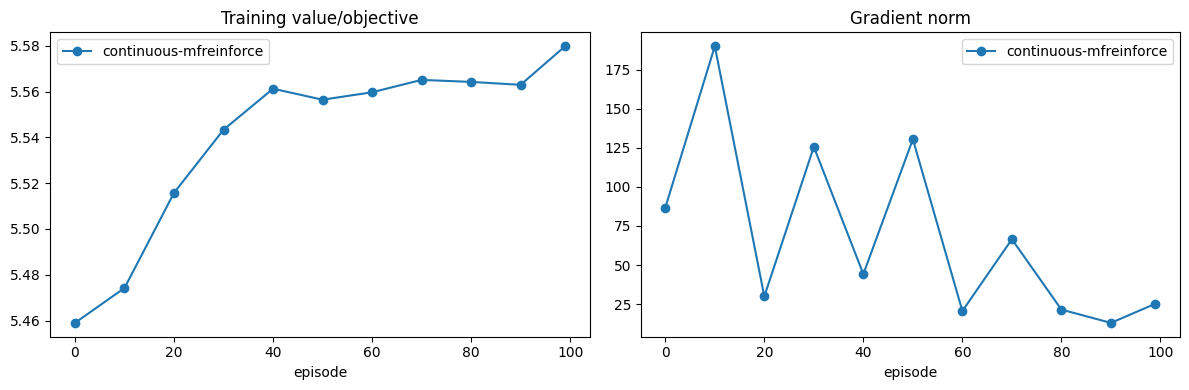

In [5]:
histories = nh.load_training_histories(bundle)
nh.plot_training_comparison(histories)

## Application Diagnostics

Goal: compare the learned continuous controller against the exact LQ oracle.

Reference: all optimal curves and policy columns use the Riccati/closed-form LQ oracle, so gaps are exact up to numerical precision.

The moment plots show learned and optimal

$$
m_t=\mathbb{E}[X_t],
\qquad
v_t=\operatorname{Var}(X_t),
$$

while the policy panels compare learned gains with optimal gains. Terminal quantiles and landscape slices summarize the distributional and local-objective behavior around the learned solution.

,algorithm,reference_kind,learned_cost,optimal_cost,objective_gap
0,continuous-mfreinforce,riccati_exact_optimizer,5.579806,2.928034,2.651772


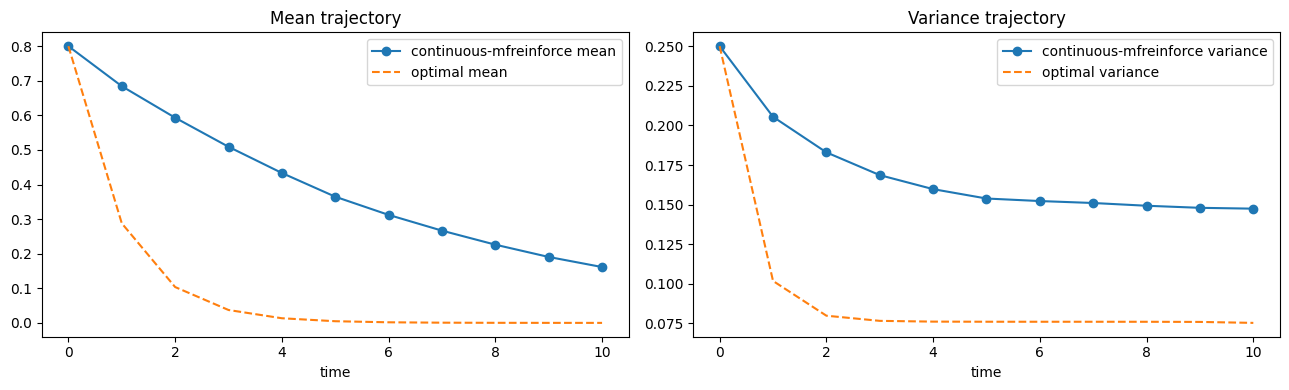

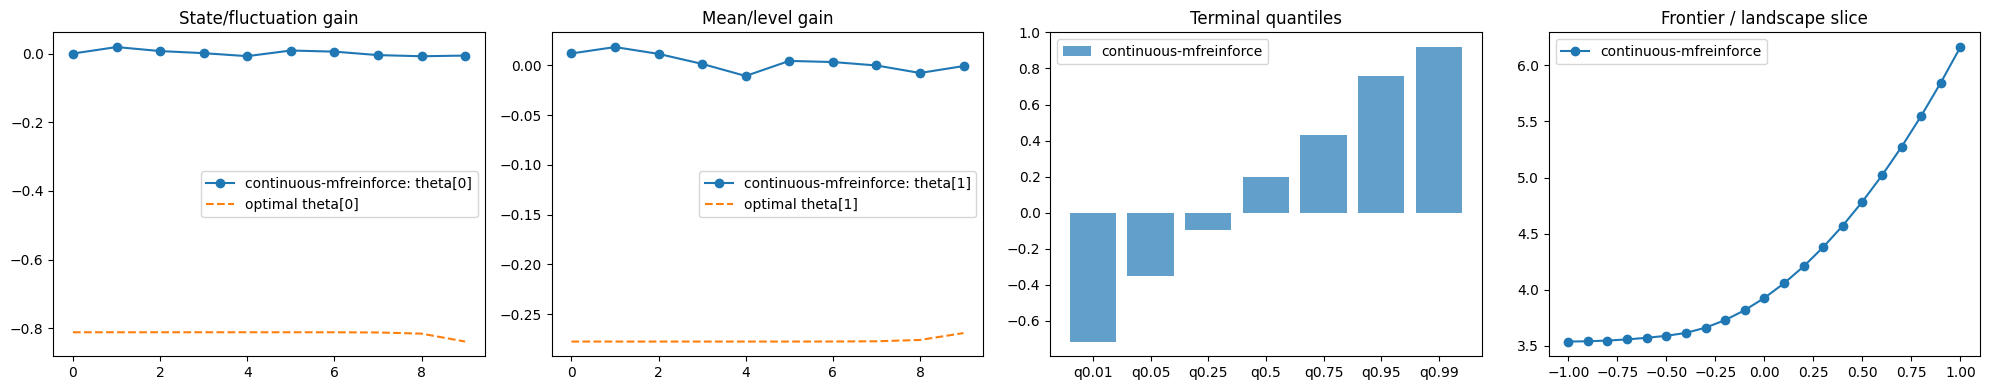

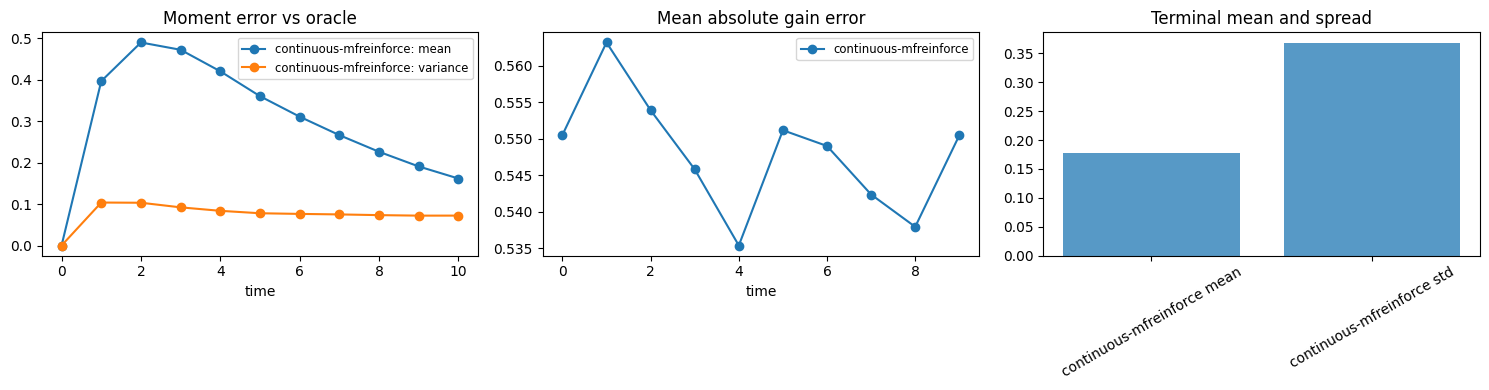

In [6]:
application = nh.load_application_data(bundle)
display(nh.reference_solution_table(ENV_NAME, application))
nh.plot_continuous_time_metrics(application, ENV_NAME)
nh.plot_continuous_policy_and_samples(application, ENV_NAME)
nh.plot_continuous_snapshots(application, ENV_NAME)
nh.plot_continuous_application_details(application, ENV_NAME)

## Universal Diagnostics

Goal: validate the estimator chain before interpreting optimization performance.

The perturbation plots measure empirical geometry,

$$
d(M^\lambda,\mu),
$$

including quantile bands and local log-log slopes. The functional-law plots study

$$
\Gamma(M^\lambda)=(F_1(M^\lambda),\ldots,F_k(M^\lambda)),
\qquad
\frac{\Gamma(M^\lambda)-\Gamma(\mu)}{\lambda},
$$

which is the induced law of population signatures. The score plots check

$$
S_{t,\lambda}^\theta=\nabla_\theta\log q_{t,\lambda}^\theta(M_t),
\qquad \mathbb{E}[S_{t,\lambda}^\theta]\approx 0,
$$

and the gradient plots report bias, variance, MSE, norm ratio, and cosine agreement for an estimator $\widehat g$ against an oracle or reference gradient $g$:

$$
\operatorname{MSE}=\mathbb{E}\|\widehat g-g\|_2^2,
\qquad
\cos(\widehat g,g)=\frac{\widehat g\cdot g}{\|\widehat g\|_2\|g\|_2}.
$$

The sensitivity plots track errors in $D_t=\partial_\theta\Gamma(\mu_t^\theta)$, or in the finite-state case $D_t=\partial_\theta\mu_t^\theta$.

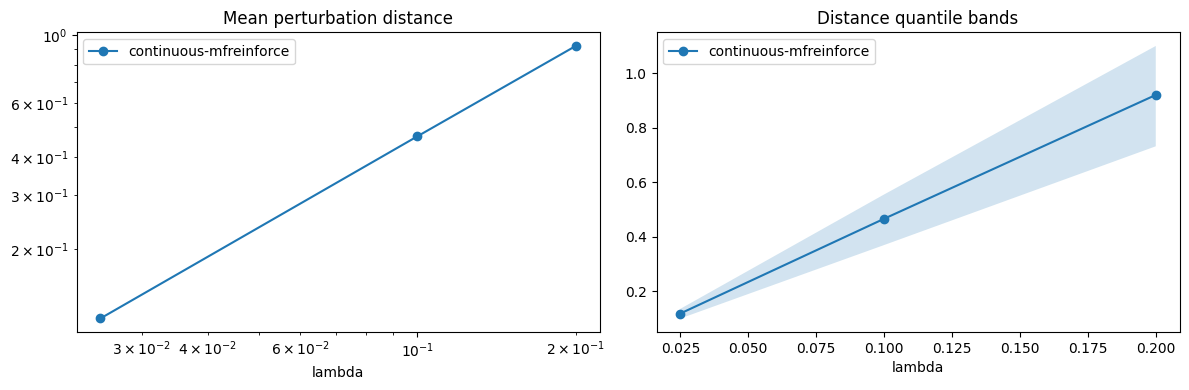

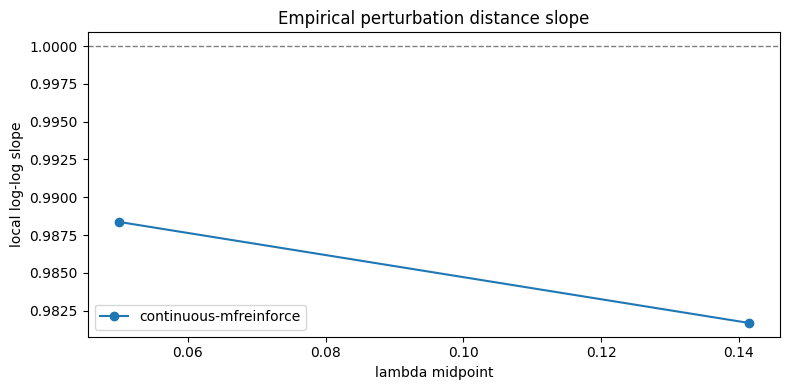

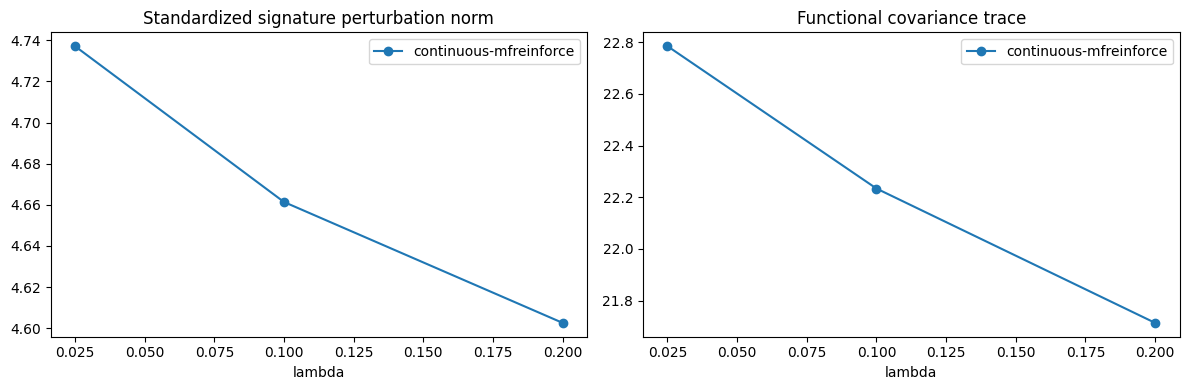

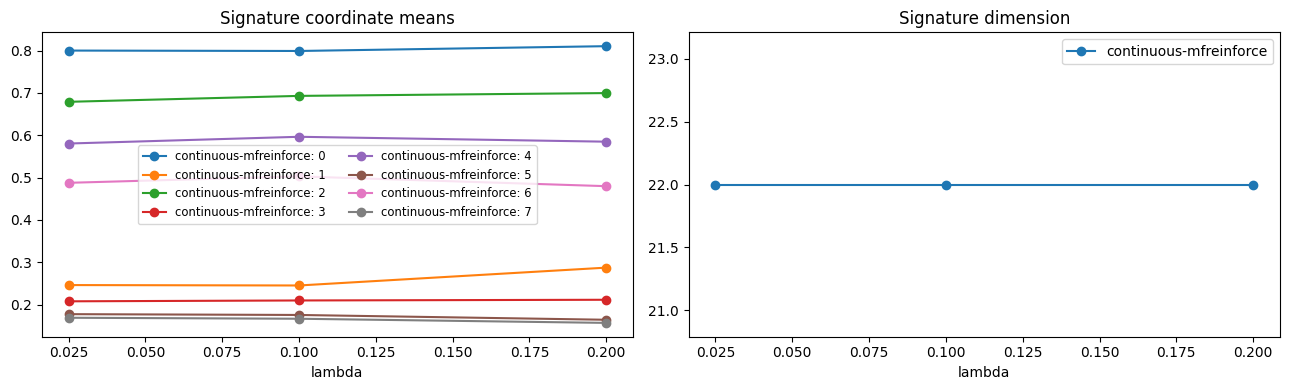

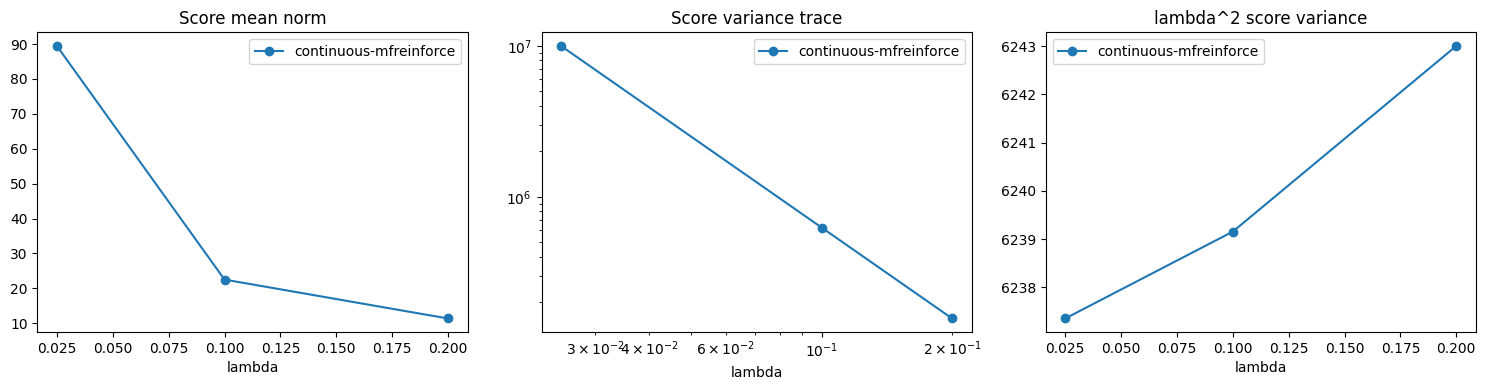

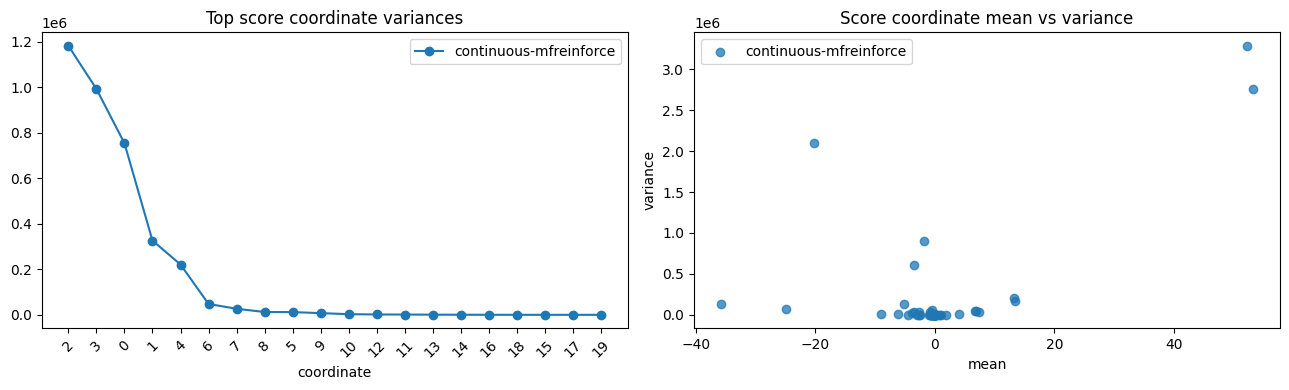

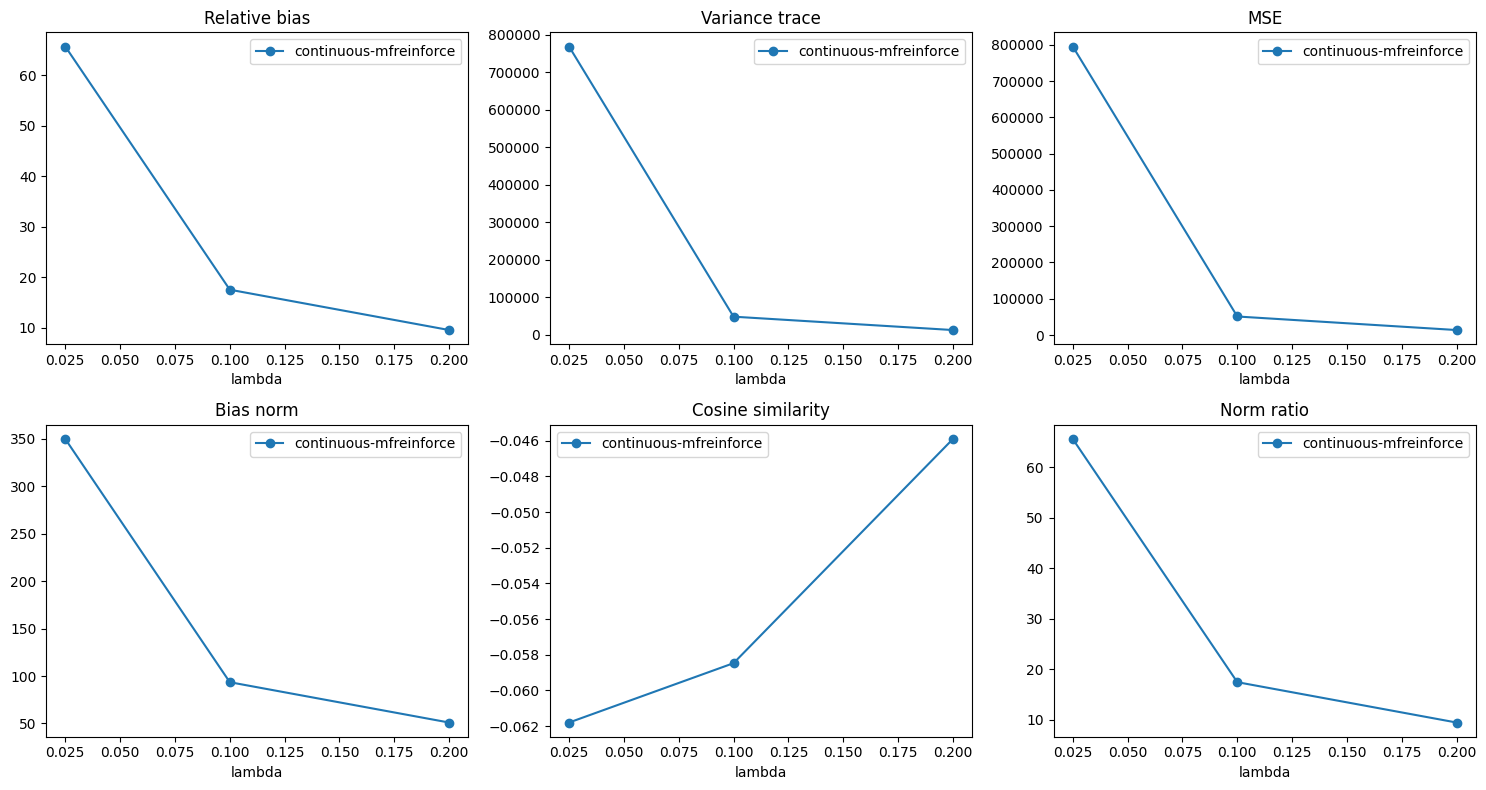

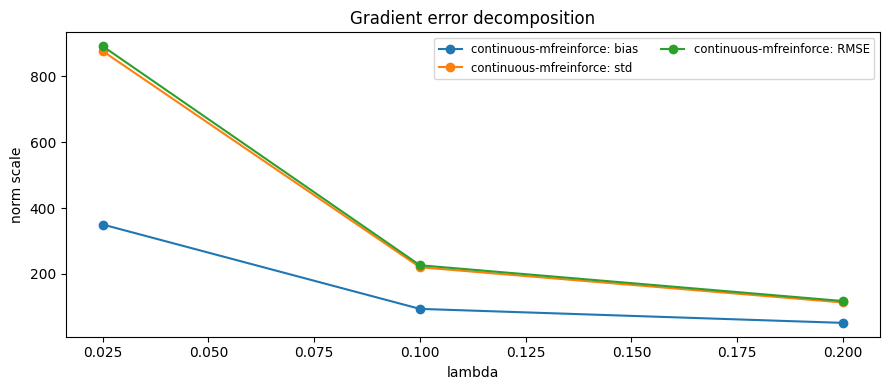

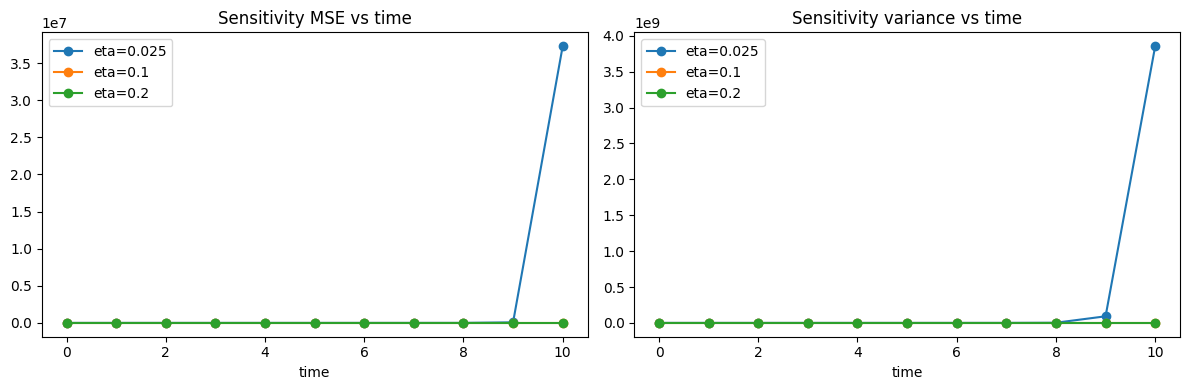

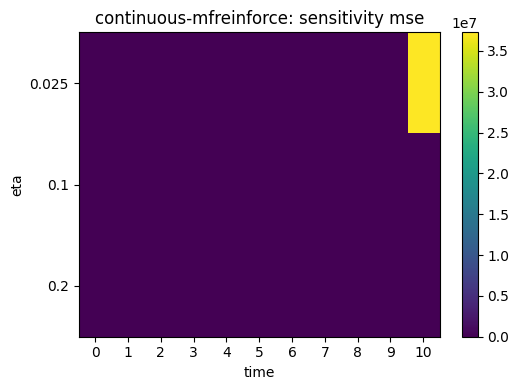

In [7]:
diagnostics = nh.load_diagnostic_data(bundle)
nh.plot_perturbation_geometry(diagnostics)
nh.plot_perturbation_slopes(diagnostics)
nh.plot_functional_law(diagnostics)
nh.plot_functional_signature_means(diagnostics)
nh.plot_score_validation(diagnostics)
nh.plot_score_coordinate_diagnostics(diagnostics)
nh.plot_gradient_validation(diagnostics)
nh.plot_gradient_error_decomposition(diagnostics)
nh.plot_sensitivity_validation(diagnostics)
nh.plot_sensitivity_heatmap(diagnostics)

## Scaling, Budget, And Optimization Summaries

Goal: measure how estimator quality and optimization performance change with simulator budget, auxiliary budget, horizon, and training time.

The budget heatmap varies main and auxiliary samples $(B,n)$ under the approximate cost model

$$
C\approx C_{main}B+C_{aux}n.
$$

The horizon plot studies how gradient error changes with $T$, and the optimization plots compare objective or cost gaps against iteration count, runtime, and simulator-call budget.

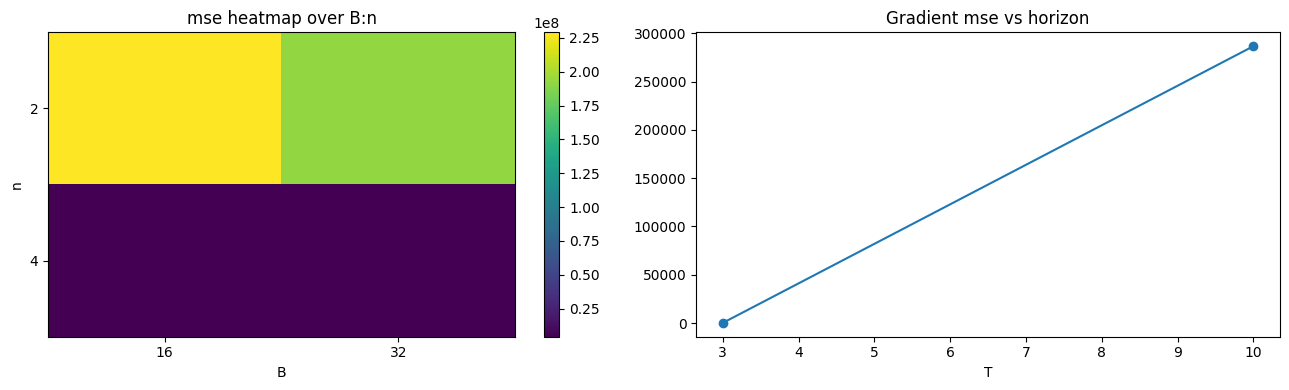

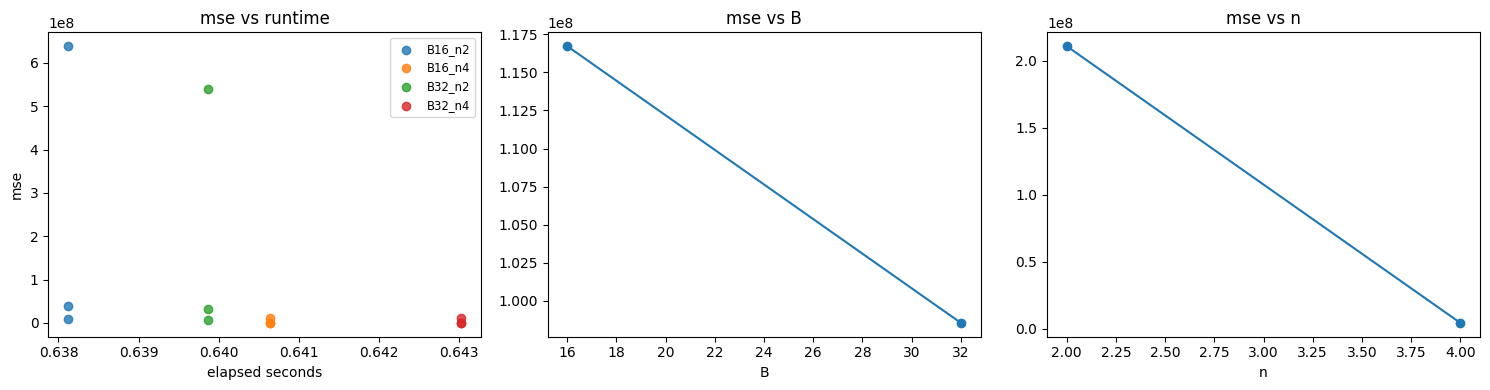

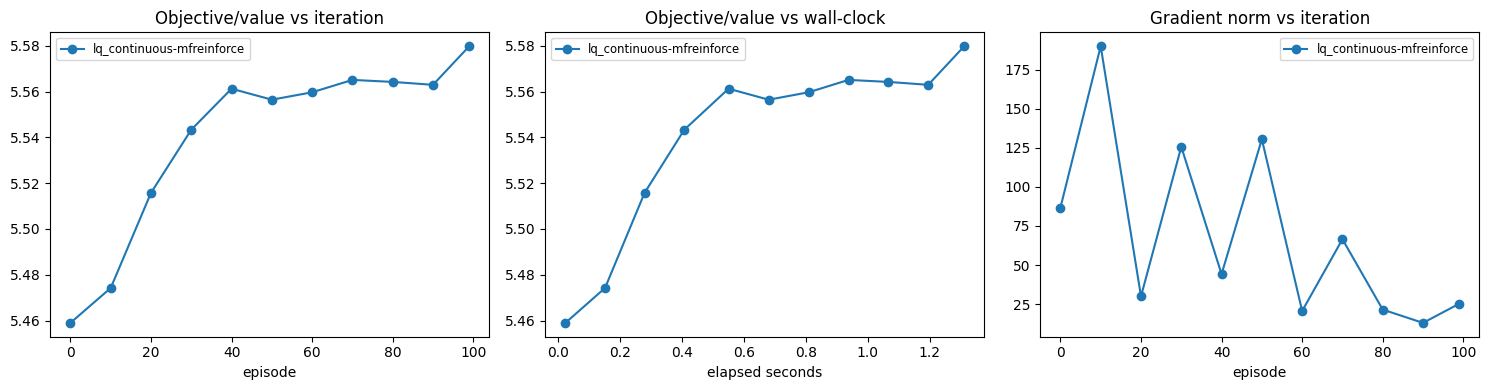

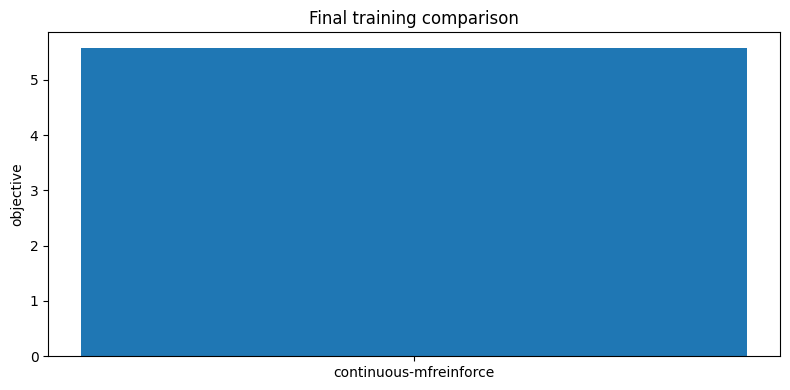

In [8]:
studies = nh.load_study_data(bundle)
grid_metrics = nh.load_study_grid_metrics(bundle)
optimization_history = nh.load_optimization_history(bundle)
nh.plot_budget_and_horizon(studies)
nh.plot_budget_pareto(studies, grid_metrics)
nh.plot_optimization_history(optimization_history)
nh.plot_optimization_summary(studies)

## Raw Tables For Custom Figures

Goal: expose the underlying CSV/JSON artifacts used by the plots so paper figures can be restyled or recomputed without rerunning training.

These tables are not new estimators. They are the saved values for population flows, policies, diagnostics, study grids, histories, and final metrics.

In [9]:
application[nh.CONTINUOUS_ALGORITHM]["time_metrics"].head(), diagnostics[nh.CONTINUOUS_ALGORITHM]["gradient"].head(), studies["budget"].head()

(  env  time      mean  variance  optimal_mean  optimal_variance  mean_error  \
 0  lq     0  0.800000  0.250000      0.800000          0.250000    0.000000   
 1  lq     1  0.684306  0.205418      0.287946          0.101831    0.396360   
 2  lq     2  0.593139  0.182977      0.103641          0.079888    0.489499   
 3  lq     3  0.509172  0.168613      0.037304          0.076638    0.471868   
 4  lq     4  0.433385  0.159768      0.013427          0.076156    0.419958   
 
    variance_error  
 0        0.000000  
 1        0.103587  
 2        0.103089  
 3        0.091976  
 4        0.083612  ,
    lambda  replications  estimate_norm  variance_trace  \
 0   0.025             8     349.544669   768877.690289   
 1   0.100             8      93.075716    48422.191181   
 2   0.200             8      50.483096    12770.050846   
 
    covariance_largest_eigenvalue  oracle_norm   bias_norm  relative_bias  \
 0                  536541.578790     5.324946  349.914145      65.712238   